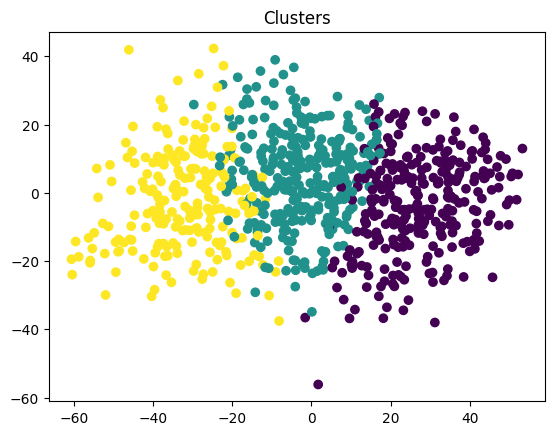

In [2]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned.csv")

# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Dynamically find columns
dance_col = next((c for c in df.columns if "dance" in c), None)
energy_col = next((c for c in df.columns if "energy" in c), None)
valence_col = next((c for c in df.columns if "valence" in c), None)
tempo_col = next((c for c in df.columns if "tempo" in c), None)

cols = [c for c in [dance_col, energy_col, valence_col, tempo_col] if c]

# Convert to numeric
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols)

# Select features
X = df[cols]

# KMeans
kmeans = KMeans(n_clusters=3, n_init=10)
df['cluster_label'] = kmeans.fit_predict(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_label'])
plt.title("Clusters")
plt.show()

# Save
df.to_csv("../data/clustered.csv", index=False)